Using device: cuda
LSTM Sensitivity Analysis - Feature Exclusion Experiments

################################################################################
# Experiment: Full Features
# Description: All input features (flow + rainfall + meteorology)
################################################################################
原始特征数量: 133
排除特征: []
剩余特征数量: 133
每个时间步特征数: 19

Training: full
Input size: 19
Model parameters: 128129
Epoch [  1/200] - Train: 2.421186 - Val: 0.862293
Epoch [ 50/200] - Train: 0.060956 - Val: 0.067674
Early stopping at epoch 63

Test Set Performance:
  R²:   0.9508
  NSE:  0.9455
  KGE:  0.9062
  RMSE: 180.06 m³/s
  MAE:  95.03 m³/s

################################################################################
# Experiment: Without Upstream Flow
# Description: Exclude upstream flow gauges (Lingxia + Baipenzhu)
################################################################################
原始特征数量: 133
排除特征: ['岭下站流量', '白盆珠出库流量']
剩余特征数量: 119
每个时间步特征数: 17



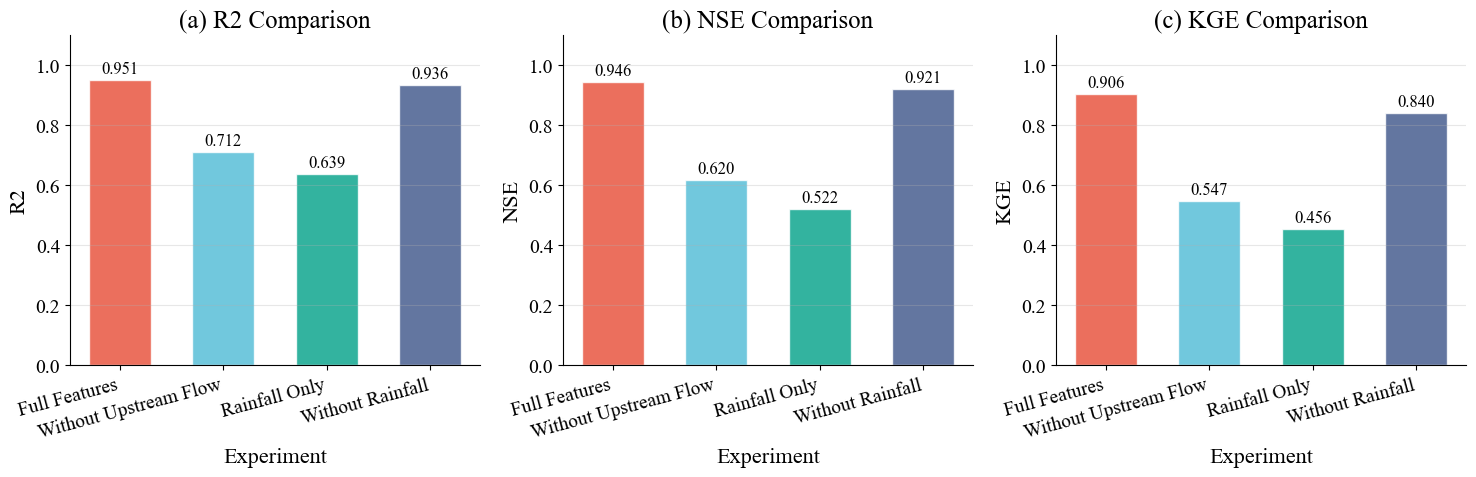

误差指标对比图已保存至: ./sensitivity_analysis/error_metrics_comparison.png


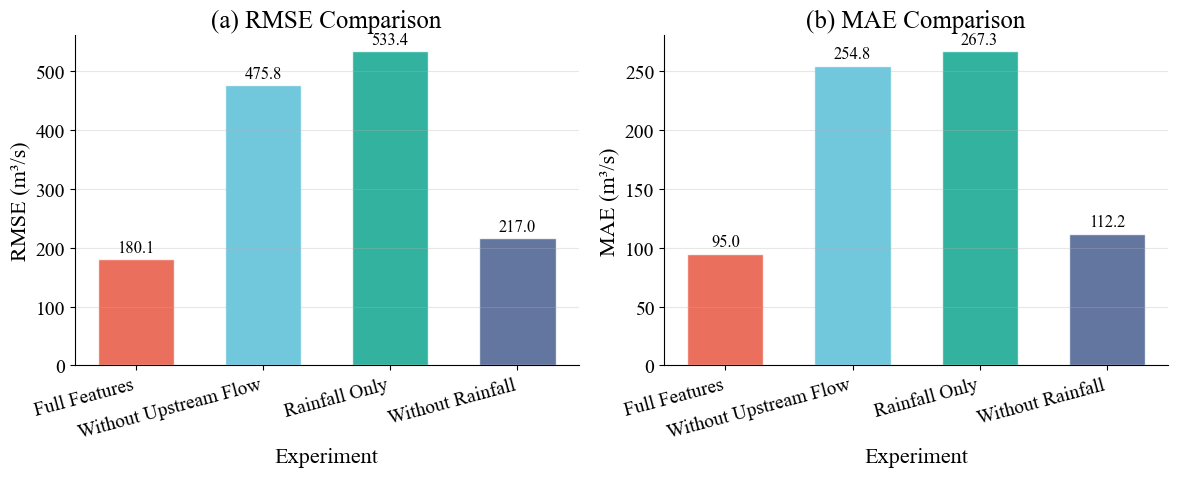

散点图对比已保存至: ./sensitivity_analysis/scatter_comparison.png


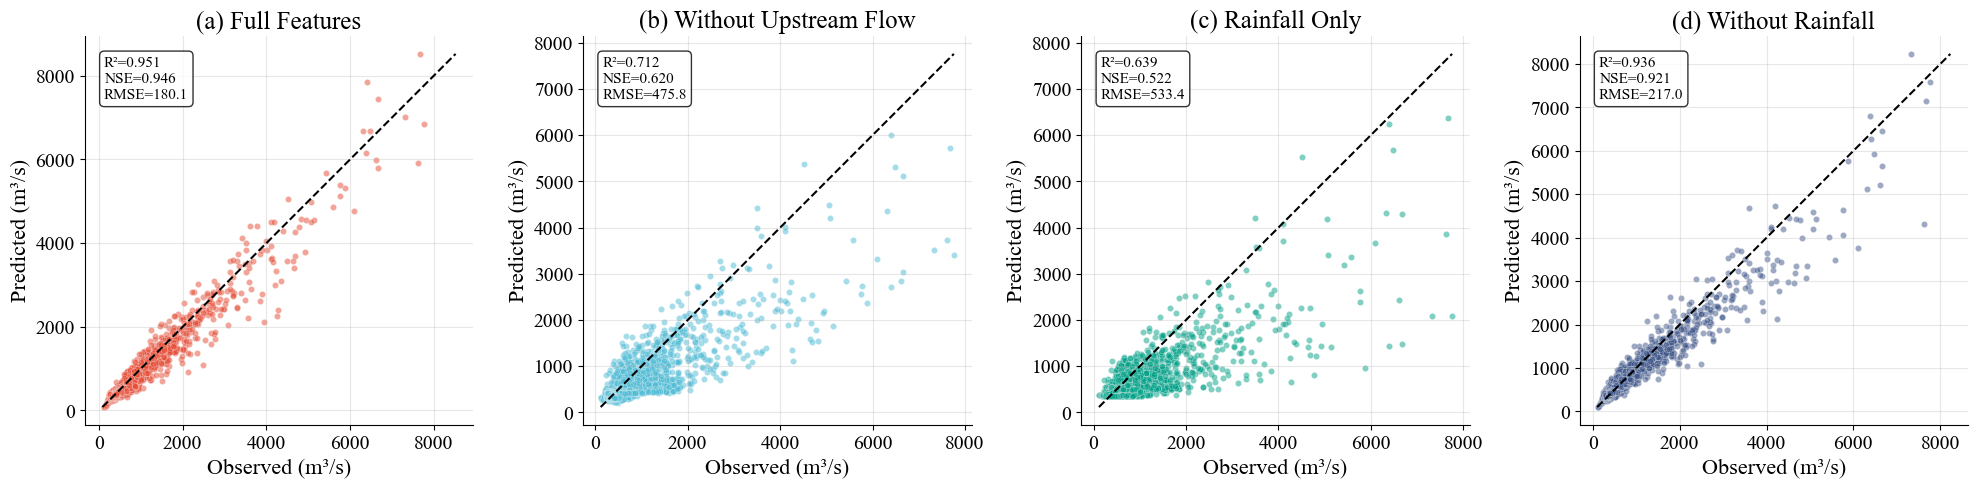

时间序列对比图已保存至: ./sensitivity_analysis/timeseries_comparison.png


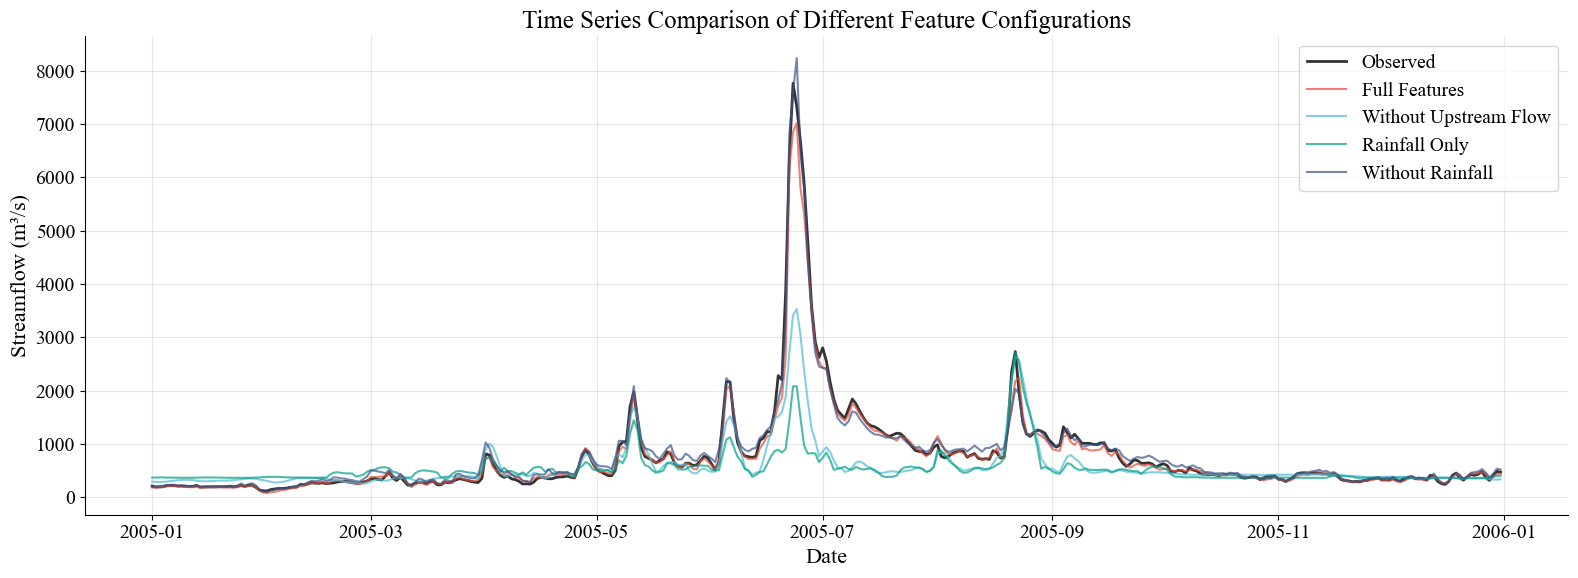

AttributeError: 'DatetimeIndex' object has no attribute 'iloc'

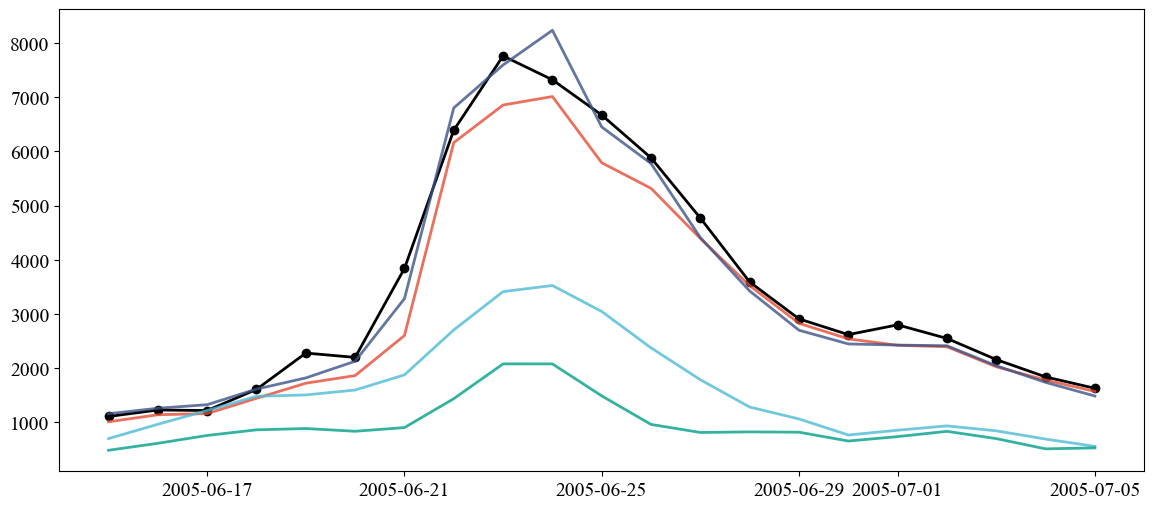

In [1]:
"""
LSTM Sensitivity Analysis - Feature Exclusion Experiments
Boluo Watershed Streamflow Prediction
Response to Reviewer: Excluding upstream flow / rainfall-only inputs
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import joblib
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 绘图设置
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 14

#==============================================================================
# 1. Feature Configuration
#==============================================================================
# 特征分类
FEATURE_GROUPS = {
    # 流量站点
    'flow': ['岭下站流量', '白盆珠出库流量'],
    # 降雨站点
    'rainfall': ['大陂布', '安墩', '平山', '平潭', '惠阳', '横沥', '洋潭', 
                 '淡水', '清林径', '花树下', '范家田', '上坪', '三洲田', '博罗'],
    # 气象因子
    'meteorology': ['博罗_T', '博罗_P', '博罗_E']
}

# 实验配置
EXPERIMENTS = {
    'full': {
        'name': 'Full Features',
        'description': 'All input features (flow + rainfall + meteorology)',
        'exclude': [],
        'color': '#E64B35'
    },
    'no_flow': {
        'name': 'Without Upstream Flow',
        'description': 'Exclude upstream flow gauges (Lingxia + Baipenzhu)',
        'exclude': ['岭下站流量', '白盆珠出库流量'],
        'color': '#4DBBD5'
    },
    'rainfall_only': {
        'name': 'Rainfall Only',
        'description': 'Only rainfall station inputs',
        'exclude': ['岭下站流量', '白盆珠出库流量', '博罗_T', '博罗_P', '博罗_E'],
        'color': '#00A087'
    },
    'no_rainfall': {
        'name': 'Without Rainfall',
        'description': 'Exclude all rainfall stations',
        'exclude': ['大陂布', '安墩', '平山', '平潭', '惠阳', '横沥', '洋潭', 
                   '淡水', '清林径', '花树下', '范家田', '上坪', '三洲田', '博罗'],
        'color': '#3C5488'
    }
}

#==============================================================================
# 2. Evaluation Metrics
#==============================================================================
def calc_nse(observed, predicted):
    return 1 - np.sum((observed - predicted)**2) / np.sum((observed - np.mean(observed))**2)

def calc_kge(observed, predicted):
    r = np.corrcoef(observed, predicted)[0, 1]
    alpha = np.std(predicted) / np.std(observed)
    beta = np.mean(predicted) / np.mean(observed)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def evaluate_model(observed, predicted, print_results=True):
    r2 = np.corrcoef(observed, predicted)[0, 1]**2
    nse = calc_nse(observed, predicted)
    kge = calc_kge(observed, predicted)
    rmse = np.sqrt(mean_squared_error(observed, predicted))
    mae = mean_absolute_error(observed, predicted)
    
    if print_results:
        print(f"  R²:   {r2:.4f}")
        print(f"  NSE:  {nse:.4f}")
        print(f"  KGE:  {kge:.4f}")
        print(f"  RMSE: {rmse:.2f} m³/s")
        print(f"  MAE:  {mae:.2f} m³/s")
    
    return {'R2': r2, 'NSE': nse, 'KGE': kge, 'RMSE': rmse, 'MAE': mae}

#==============================================================================
# 3. Data Loading with Feature Selection
#==============================================================================
def get_feature_columns(all_columns, exclude_base_features):
    """根据排除列表筛选特征列"""
    selected_cols = []
    for col in all_columns:
        # 检查该列的基础特征是否在排除列表中
        base_feature = col.replace('_lag_1', '').replace('_lag_2', '').replace('_lag_3', '') \
                         .replace('_lag_4', '').replace('_lag_5', '').replace('_lag_6', '').replace('_lag_7', '')
        if base_feature not in exclude_base_features:
            selected_cols.append(col)
    return selected_cols

def load_and_prepare_data(train_path, test_path, exclude_features=[]):
    """加载数据并根据配置排除特定特征"""
    train_df = pd.read_csv(train_path, encoding='utf-8')
    test_df = pd.read_csv(test_path, encoding='utf-8')
    
    cols = train_df.columns.tolist()
    target_col = cols[-2]  # 博罗站流量
    date_col = cols[-1]    # date
    all_feature_cols = cols[:-2]
    
    # 筛选特征
    feature_cols = get_feature_columns(all_feature_cols, exclude_features)
    
    print(f"原始特征数量: {len(all_feature_cols)}")
    print(f"排除特征: {exclude_features}")
    print(f"剩余特征数量: {len(feature_cols)}")
    
    X_train = train_df[feature_cols].values.astype(np.float32)
    y_train = train_df[target_col].values.astype(np.float32)
    X_test = test_df[feature_cols].values.astype(np.float32)
    y_test = test_df[target_col].values.astype(np.float32)
    test_dates = test_df[date_col].values
    
    # 标准化
    scaler_X = MinMaxScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    scaler_y = MinMaxScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
    
    # 重塑为LSTM格式
    n_lag = 7
    n_features_per_lag = len(feature_cols) // n_lag
    
    print(f"每个时间步特征数: {n_features_per_lag}")
    
    X_train_reshaped = X_train_scaled.reshape(-1, n_lag, n_features_per_lag).astype(np.float32)
    X_test_reshaped = X_test_scaled.reshape(-1, n_lag, n_features_per_lag).astype(np.float32)
    
    return {
        'X_train': X_train_reshaped,
        'y_train': y_train_scaled.astype(np.float32),
        'X_test': X_test_reshaped,
        'y_test': y_test_scaled.astype(np.float32),
        'y_train_original': y_train,
        'y_test_original': y_test,
        'test_dates': test_dates,
        'scaler_X': scaler_X,
        'scaler_y': scaler_y,
        'feature_cols': feature_cols,
        'n_features_per_lag': n_features_per_lag
    }

#==============================================================================
# 4. LSTM Model
#==============================================================================
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64], dropout=0.2, bidirectional=False):
        super(LSTMModel, self).__init__()
        
        self.num_directions = 2 if bidirectional else 1
        
        self.lstm1 = nn.LSTM(input_size, hidden_sizes[0], batch_first=True, bidirectional=bidirectional)
        self.dropout1 = nn.Dropout(dropout)
        
        lstm1_out = hidden_sizes[0] * self.num_directions
        self.lstm2 = nn.LSTM(lstm1_out, hidden_sizes[1], batch_first=True, bidirectional=bidirectional)
        self.dropout2 = nn.Dropout(dropout)
        
        lstm2_out = hidden_sizes[1] * self.num_directions
        self.fc1 = nn.Linear(lstm2_out, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 1)
        
    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out = out[:, -1, :]
        out = torch.relu(self.bn1(self.fc1(out)))
        out = self.fc2(out)
        return out

#==============================================================================
# 5. NSE Loss
#==============================================================================
class NSELoss(nn.Module):
    def __init__(self):
        super(NSELoss, self).__init__()
        
    def forward(self, pred, target):
        ss_res = torch.sum((target - pred) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return ss_res / (ss_tot + 1e-8)

#==============================================================================
# 6. Training Function
#==============================================================================
def train_model(data, params, output_dir='./', experiment_name='full'):
    """训练单个实验的模型"""
    
    print(f"\n{'='*60}")
    print(f"Training: {experiment_name}")
    print(f"{'='*60}")
    
    X_train_tensor = torch.FloatTensor(data['X_train']).to(device)
    y_train_tensor = torch.FloatTensor(data['y_train']).unsqueeze(1).to(device)
    X_test_tensor = torch.FloatTensor(data['X_test']).to(device)
    
    # 划分验证集
    val_size = int(0.1 * len(X_train_tensor))
    X_tr, X_val = X_train_tensor[:-val_size], X_train_tensor[-val_size:]
    y_tr, y_val = y_train_tensor[:-val_size], y_train_tensor[-val_size:]
    
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=params['batch_size'], shuffle=True)
    
    # 构建模型
    model = LSTMModel(
        input_size=data['n_features_per_lag'],
        hidden_sizes=[params['hidden_size1'], params['hidden_size2']],
        dropout=params['dropout'],
        bidirectional=params.get('bidirectional', False)
    ).to(device)
    
    print(f"Input size: {data['n_features_per_lag']}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    
    criterion = NSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(params['epochs']):
        # Training
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        scheduler.step(val_loss)
        
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:3d}/{params['epochs']}] - Train: {train_loss:.6f} - Val: {val_loss:.6f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= params['patience']:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Load best model
    model.load_state_dict(best_model_state)
    model.eval()
    
    # Predictions
    with torch.no_grad():
        y_test_pred = model(X_test_tensor).cpu().numpy().flatten()
        y_train_pred = model(X_train_tensor).cpu().numpy().flatten()
    
    y_test_pred = data['scaler_y'].inverse_transform(y_test_pred.reshape(-1, 1)).flatten()
    y_train_pred = data['scaler_y'].inverse_transform(y_train_pred.reshape(-1, 1)).flatten()
    
    # Evaluate
    print("\nTest Set Performance:")
    test_metrics = evaluate_model(data['y_test_original'], y_test_pred)
    
    # Save predictions
    exp_output_dir = os.path.join(output_dir, experiment_name)
    os.makedirs(exp_output_dir, exist_ok=True)
    
    pd.DataFrame({
        'Date': data['test_dates'],
        'Observed': data['y_test_original'],
        'Predicted': y_test_pred,
        'Residual': data['y_test_original'] - y_test_pred
    }).to_csv(os.path.join(exp_output_dir, 'predictions.csv'), index=False, encoding='utf-8-sig')
    
    # Save model
    torch.save(model.state_dict(), os.path.join(exp_output_dir, 'model.pth'))
    
    return {
        'model': model,
        'history': history,
        'test_metrics': test_metrics,
        'predictions': y_test_pred,
        'observed': data['y_test_original'],
        'dates': data['test_dates']
    }

#==============================================================================
# 7. Visualization Functions
#==============================================================================
def plot_metrics_comparison(results, output_dir):
    """绘制各实验指标对比柱状图"""
    
    experiments = list(results.keys())
    metrics = ['R2', 'NSE', 'KGE']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    x = np.arange(len(experiments))
    width = 0.6
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        values = [results[exp]['test_metrics'][metric] for exp in experiments]
        colors = [EXPERIMENTS[exp]['color'] for exp in experiments]
        
        bars = ax.bar(x, values, width, color=colors, alpha=0.8, edgecolor='white')
        
        # 添加数值标签
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=12)
        
        ax.set_xlabel('Experiment')
        ax.set_ylabel(metric)
        ax.set_title(f'({chr(97+i)}) {metric} Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels([EXPERIMENTS[exp]['name'] for exp in experiments], rotation=15, ha='right')
        ax.set_ylim(0, 1.1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'metrics_comparison.png'), dpi=300, bbox_inches='tight')
    print(f"\n指标对比图已保存至: {os.path.join(output_dir, 'metrics_comparison.png')}")
    plt.show()

def plot_error_metrics_comparison(results, output_dir):
    """绘制误差指标对比"""
    
    experiments = list(results.keys())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    x = np.arange(len(experiments))
    width = 0.6
    
    # RMSE
    ax = axes[0]
    values = [results[exp]['test_metrics']['RMSE'] for exp in experiments]
    colors = [EXPERIMENTS[exp]['color'] for exp in experiments]
    bars = ax.bar(x, values, width, color=colors, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
               f'{val:.1f}', ha='center', va='bottom', fontsize=12)
    ax.set_xlabel('Experiment')
    ax.set_ylabel('RMSE (m³/s)')
    ax.set_title('(a) RMSE Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels([EXPERIMENTS[exp]['name'] for exp in experiments], rotation=15, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    
    # MAE
    ax = axes[1]
    values = [results[exp]['test_metrics']['MAE'] for exp in experiments]
    bars = ax.bar(x, values, width, color=colors, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
               f'{val:.1f}', ha='center', va='bottom', fontsize=12)
    ax.set_xlabel('Experiment')
    ax.set_ylabel('MAE (m³/s)')
    ax.set_title('(b) MAE Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels([EXPERIMENTS[exp]['name'] for exp in experiments], rotation=15, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'error_metrics_comparison.png'), dpi=300, bbox_inches='tight')
    print(f"误差指标对比图已保存至: {os.path.join(output_dir, 'error_metrics_comparison.png')}")
    plt.show()

def plot_timeseries_comparison(results, output_dir, start_idx=0, end_idx=365):
    """绘制时间序列对比图"""
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # 绘制观测值
    observed = results['full']['observed'][start_idx:end_idx]
    dates = pd.to_datetime(results['full']['dates'][start_idx:end_idx])
    ax.plot(dates, observed, 'k-', linewidth=2, label='Observed', alpha=0.8)
    
    # 绘制各实验预测值
    for exp_name, exp_results in results.items():
        predictions = exp_results['predictions'][start_idx:end_idx]
        color = EXPERIMENTS[exp_name]['color']
        label = EXPERIMENTS[exp_name]['name']
        ax.plot(dates, predictions, color=color, linewidth=1.5, label=label, alpha=0.7)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Streamflow (m³/s)')
    ax.set_title('Time Series Comparison of Different Feature Configurations')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'timeseries_comparison.png'), dpi=300, bbox_inches='tight')
    print(f"时间序列对比图已保存至: {os.path.join(output_dir, 'timeseries_comparison.png')}")
    plt.show()

def plot_scatter_comparison(results, output_dir):
    """绘制散点图对比"""
    
    n_exp = len(results)
    fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 5))
    
    for i, (exp_name, exp_results) in enumerate(results.items()):
        ax = axes[i] if n_exp > 1 else axes
        
        observed = exp_results['observed']
        predicted = exp_results['predictions']
        color = EXPERIMENTS[exp_name]['color']
        
        ax.scatter(observed, predicted, c=color, alpha=0.5, s=20, edgecolor='white', linewidth=0.3)
        
        # 1:1线
        max_val = max(observed.max(), predicted.max())
        min_val = min(observed.min(), predicted.min())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5)
        
        # 指标
        metrics = exp_results['test_metrics']
        text_str = f"R²={metrics['R2']:.3f}\nNSE={metrics['NSE']:.3f}\nRMSE={metrics['RMSE']:.1f}"
        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=11)
        
        ax.set_xlabel('Observed (m³/s)')
        ax.set_ylabel('Predicted (m³/s)')
        ax.set_title(f'({chr(97+i)}) {EXPERIMENTS[exp_name]["name"]}')
        ax.set_aspect('equal', adjustable='box')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'scatter_comparison.png'), dpi=300, bbox_inches='tight')
    print(f"散点图对比已保存至: {os.path.join(output_dir, 'scatter_comparison.png')}")
    plt.show()

def plot_flood_event_comparison(results, output_dir, flood_start='2005-06-15', flood_end='2005-07-05'):
    """绘制洪水事件对比图"""
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 找到洪水事件的索引
    dates = pd.to_datetime(results['full']['dates'])
    mask = (dates >= flood_start) & (dates <= flood_end)
    flood_dates = dates[mask]
    
    # 绘制观测值
    observed = results['full']['observed'][mask]
    ax.plot(flood_dates, observed, 'ko-', linewidth=2, markersize=6, label='Observed')
    
    # 绘制各实验预测值
    for exp_name, exp_results in results.items():
        predictions = exp_results['predictions'][mask]
        color = EXPERIMENTS[exp_name]['color']
        label = EXPERIMENTS[exp_name]['name']
        ax.plot(flood_dates, predictions, color=color, linewidth=2, label=label, alpha=0.8)
    
    # 标记洪峰
    peak_idx = observed.argmax()
    peak_date = flood_dates.iloc[peak_idx]
    peak_value = observed.iloc[peak_idx]
    ax.scatter(peak_date, peak_value, color='red', s=100, zorder=5, marker='*')
    ax.annotate(f'Peak: {peak_value:.0f}', xy=(peak_date, peak_value), 
                xytext=(10, 10), textcoords='offset points', fontsize=12, color='red')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Streamflow (m³/s)')
    ax.set_title('Flood Event Comparison (June-July 2005)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'flood_event_comparison.png'), dpi=300, bbox_inches='tight')
    print(f"洪水事件对比图已保存至: {os.path.join(output_dir, 'flood_event_comparison.png')}")
    plt.show()

#==============================================================================
# 8. Print Summary
#==============================================================================
def print_summary(results, output_dir):
    """打印并保存实验结果汇总"""
    
    print("\n" + "="*100)
    print("SENSITIVITY ANALYSIS SUMMARY")
    print("="*100)
    
    # 创建汇总表
    summary_data = []
    for exp_name, exp_results in results.items():
        metrics = exp_results['test_metrics']
        summary_data.append({
            'Experiment': EXPERIMENTS[exp_name]['name'],
            'Description': EXPERIMENTS[exp_name]['description'],
            'R²': metrics['R2'],
            'NSE': metrics['NSE'],
            'KGE': metrics['KGE'],
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # 打印表格
    print("\n【Performance Metrics Comparison】")
    print("-"*100)
    print(f"{'Experiment':<25} {'R²':<10} {'NSE':<10} {'KGE':<10} {'RMSE':<12} {'MAE':<10}")
    print("-"*100)
    
    for _, row in summary_df.iterrows():
        print(f"{row['Experiment']:<25} {row['R²']:<10.4f} {row['NSE']:<10.4f} "
              f"{row['KGE']:<10.4f} {row['RMSE']:<12.2f} {row['MAE']:<10.2f}")
    
    print("-"*100)
    
    # 计算性能下降百分比
    full_metrics = results['full']['test_metrics']
    print("\n【Performance Degradation Relative to Full Model】")
    print("-"*100)
    print(f"{'Experiment':<25} {'ΔR²':<12} {'ΔNSE':<12} {'ΔKGE':<12} {'ΔRMSE(%)':<12}")
    print("-"*100)
    
    for exp_name, exp_results in results.items():
        if exp_name == 'full':
            continue
        metrics = exp_results['test_metrics']
        delta_r2 = metrics['R2'] - full_metrics['R2']
        delta_nse = metrics['NSE'] - full_metrics['NSE']
        delta_kge = metrics['KGE'] - full_metrics['KGE']
        delta_rmse_pct = (metrics['RMSE'] - full_metrics['RMSE']) / full_metrics['RMSE'] * 100
        
        print(f"{EXPERIMENTS[exp_name]['name']:<25} {delta_r2:<12.4f} {delta_nse:<12.4f} "
              f"{delta_kge:<12.4f} {delta_rmse_pct:<12.1f}%")
    
    print("-"*100)
    
    # 保存汇总表
    summary_df.to_csv(os.path.join(output_dir, 'sensitivity_analysis_summary.csv'), index=False)
    print(f"\n汇总表已保存至: {os.path.join(output_dir, 'sensitivity_analysis_summary.csv')}")
    
    # 关键发现
    print("\n【Key Findings】")
    print("-"*100)
    
    no_flow_nse = results['no_flow']['test_metrics']['NSE']
    no_flow_drop = (full_metrics['NSE'] - no_flow_nse) / full_metrics['NSE'] * 100
    print(f"1. Excluding upstream flow reduces NSE by {no_flow_drop:.1f}% "
          f"(from {full_metrics['NSE']:.4f} to {no_flow_nse:.4f})")
    
    rainfall_only_nse = results['rainfall_only']['test_metrics']['NSE']
    rainfall_drop = (full_metrics['NSE'] - rainfall_only_nse) / full_metrics['NSE'] * 100
    print(f"2. Using rainfall-only inputs reduces NSE by {rainfall_drop:.1f}% "
          f"(from {full_metrics['NSE']:.4f} to {rainfall_only_nse:.4f})")
    
    no_rainfall_nse = results['no_rainfall']['test_metrics']['NSE']
    no_rainfall_drop = (full_metrics['NSE'] - no_rainfall_nse) / full_metrics['NSE'] * 100
    print(f"3. Excluding rainfall reduces NSE by {no_rainfall_drop:.1f}% "
          f"(from {full_metrics['NSE']:.4f} to {no_rainfall_nse:.4f})")
    
    print("\n" + "="*100)
    
    return summary_df

#==============================================================================
# 9. Main Function
#==============================================================================
def main(train_path, test_path, output_dir='./sensitivity_analysis/', run_experiments=None):
    """主函数"""
    
    print("="*80)
    print("LSTM Sensitivity Analysis - Feature Exclusion Experiments")
    print("="*80)
    
    os.makedirs(output_dir, exist_ok=True)
    
    # 最佳超参数（从之前的训练中获得）
    best_params = {
        'hidden_size1': 128,
        'hidden_size2': 64,
        'dropout': 0.2,
        'learning_rate': 0.001,
        'batch_size': 64,
        'bidirectional': False,
        'epochs': 200,
        'patience': 30
    }
    
    # 选择要运行的实验
    if run_experiments is None:
        run_experiments = ['full', 'no_flow', 'rainfall_only', 'no_rainfall']
    
    results = {}
    
    for exp_name in run_experiments:
        if exp_name not in EXPERIMENTS:
            print(f"警告: 未知实验 {exp_name}，跳过")
            continue
        
        exp_config = EXPERIMENTS[exp_name]
        print(f"\n{'#'*80}")
        print(f"# Experiment: {exp_config['name']}")
        print(f"# Description: {exp_config['description']}")
        print(f"{'#'*80}")
        
        # 加载数据（排除指定特征）
        data = load_and_prepare_data(train_path, test_path, exp_config['exclude'])
        
        # 训练模型
        exp_results = train_model(data, best_params, output_dir, exp_name)
        results[exp_name] = exp_results
    
    # 生成可视化和汇总
    print("\n" + "="*80)
    print("Generating Visualizations...")
    print("="*80)
    
    plot_metrics_comparison(results, output_dir)
    plot_error_metrics_comparison(results, output_dir)
    plot_scatter_comparison(results, output_dir)
    plot_timeseries_comparison(results, output_dir, start_idx=0, end_idx=365)
    plot_flood_event_comparison(results, output_dir)
    
    # 打印汇总
    summary_df = print_summary(results, output_dir)
    
    print("\n敏感性分析完成！")
    print(f"所有结果已保存至: {output_dir}")
    
    return results, summary_df

#==============================================================================
if __name__ == "__main__":
    
    TRAIN_PATH = '../数据/train_data.csv'
    TEST_PATH = '../数据/test_data.csv'
    OUTPUT_DIR = './sensitivity_analysis/'
    
    # 运行所有实验
    results, summary = main(
        train_path=TRAIN_PATH,
        test_path=TEST_PATH,
        output_dir=OUTPUT_DIR,
        run_experiments=['full', 'no_flow', 'rainfall_only', 'no_rainfall']
    )

柱状图已保存至: sensitivity_analysis/sensitivity_bar_chart.png


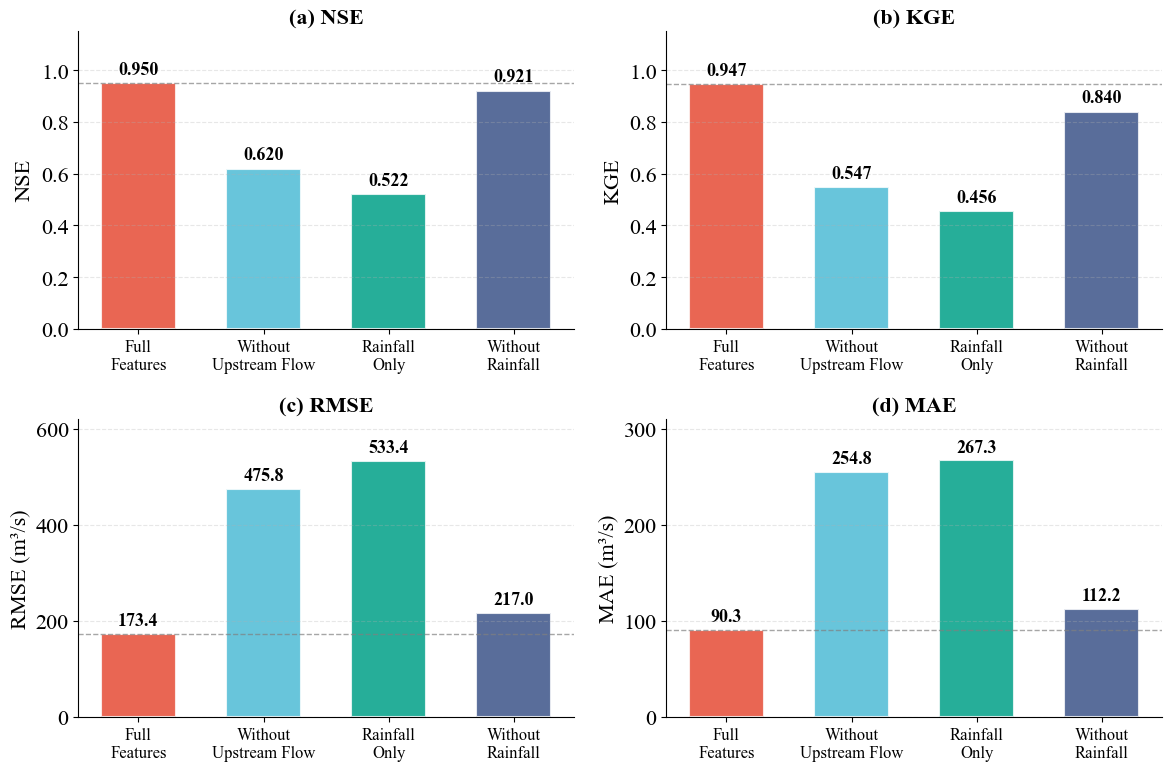


Performance Degradation Summary
Experiment                ΔNSE         ΔKGE         ΔRMSE(%)     ΔMAE(%)     
--------------------------------------------------------------------------------
Full Features             Baseline     Baseline     Baseline     Baseline    
Without Upstream Flow     -0.3298      -0.3999      +174.3      % +182.1      %
Rainfall Only             -0.4274      -0.4914      +207.5      % +195.9      %
Without Rainfall          -0.0286      -0.1072      +25.1       % +24.2       %


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 设置绘图参数
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 16

# 实验数据
experiments = ['Full\nFeatures', 'Without\nUpstream Flow', 'Rainfall\nOnly', 'Without\nRainfall']
x = np.arange(len(experiments))

# 指标数据
NSE = [0.9495, 0.6197, 0.5221, 0.9209]
KGE = [0.9472, 0.5473, 0.4558, 0.8400]
RMSE = [173.44, 475.83, 533.41, 217.03]
MAE = [90.34, 254.82, 267.28, 112.19]

# Nature配色
colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488']

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) NSE
ax = axes[0, 0]
bars = ax.bar(x, NSE, width=0.6, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, NSE):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
           f'{val:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('NSE', fontsize=16)
ax.set_title('(a) NSE', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=NSE[0], color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# (b) KGE
ax = axes[0, 1]
bars = ax.bar(x, KGE, width=0.6, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, KGE):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
           f'{val:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('KGE', fontsize=16)
ax.set_title('(b) KGE', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=KGE[0], color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# (c) RMSE
ax = axes[1, 0]
bars = ax.bar(x, RMSE, width=0.6, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, RMSE):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
           f'{val:.1f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (m³/s)', fontsize=16)
ax.set_title('(c) RMSE', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=12)
ax.set_ylim(0, 620)
ax.axhline(y=RMSE[0], color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# (d) MAE
ax = axes[1, 1]
bars = ax.bar(x, MAE, width=0.6, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, MAE):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
           f'{val:.1f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('MAE (m³/s)', fontsize=16)
ax.set_title('(d) MAE', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(experiments, fontsize=12)
ax.set_ylim(0, 310)
ax.axhline(y=MAE[0], color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')


plt.tight_layout()
plt.savefig('sensitivity_analysis/sensitivity_bar_chart.png', dpi=300, bbox_inches='tight')
print("柱状图已保存至: sensitivity_analysis/sensitivity_bar_chart.png")
plt.show()

# ========== 打印性能下降百分比 ==========
print("\n" + "="*80)
print("Performance Degradation Summary")
print("="*80)
print(f"{'Experiment':<25} {'ΔNSE':<12} {'ΔKGE':<12} {'ΔRMSE(%)':<12} {'ΔMAE(%)':<12}")
print("-"*80)

exp_names = ['Full Features', 'Without Upstream Flow', 'Rainfall Only', 'Without Rainfall']
for i, exp in enumerate(exp_names):
    if i == 0:
        print(f"{exp:<25} {'Baseline':<12} {'Baseline':<12} {'Baseline':<12} {'Baseline':<12}")
    else:
        delta_nse = NSE[i] - NSE[0]
        delta_kge = KGE[i] - KGE[0]
        delta_rmse = (RMSE[i] - RMSE[0]) / RMSE[0] * 100
        delta_mae = (MAE[i] - MAE[0]) / MAE[0] * 100
        print(f"{exp:<25} {delta_nse:<12.4f} {delta_kge:<12.4f} {delta_rmse:<+12.1f}% {delta_mae:<+12.1f}%")

